## Visualize local peaks and valleys with Swings

Bind an indicator to `Swings` to find peaks and valleys on its series — `Swings(ROC(20), span=5)` or equivalently `ROC(20) @ Swings(span=5)`. Without an indicator, `Swings` marks peaks on the `high` and valleys on the `low` of the prices frame.

In [1]:
import yfinance as yf

from mplchart.chart import Chart

from mplchart.primitives import Candlesticks, OHLC, Volume, Swings

from mplchart.indicators import SMA, EMA, ROC, MACD, PPO
from mplchart.utils import normalize_prices

In [2]:
ticker = "AAPL"
prices = normalize_prices(yf.Ticker(ticker).history(period="5y"))
prices.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 1255 entries, 2021-07-19 00:00:00-04:00 to 2026-07-17 00:00:00-04:00
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   open          1255 non-null   float64
 1   high          1255 non-null   float64
 2   low           1255 non-null   float64
 3   close         1255 non-null   float64
 4   volume        1255 non-null   int64  
 5   dividends     1255 non-null   float64
 6   stock splits  1255 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 78.4 KB


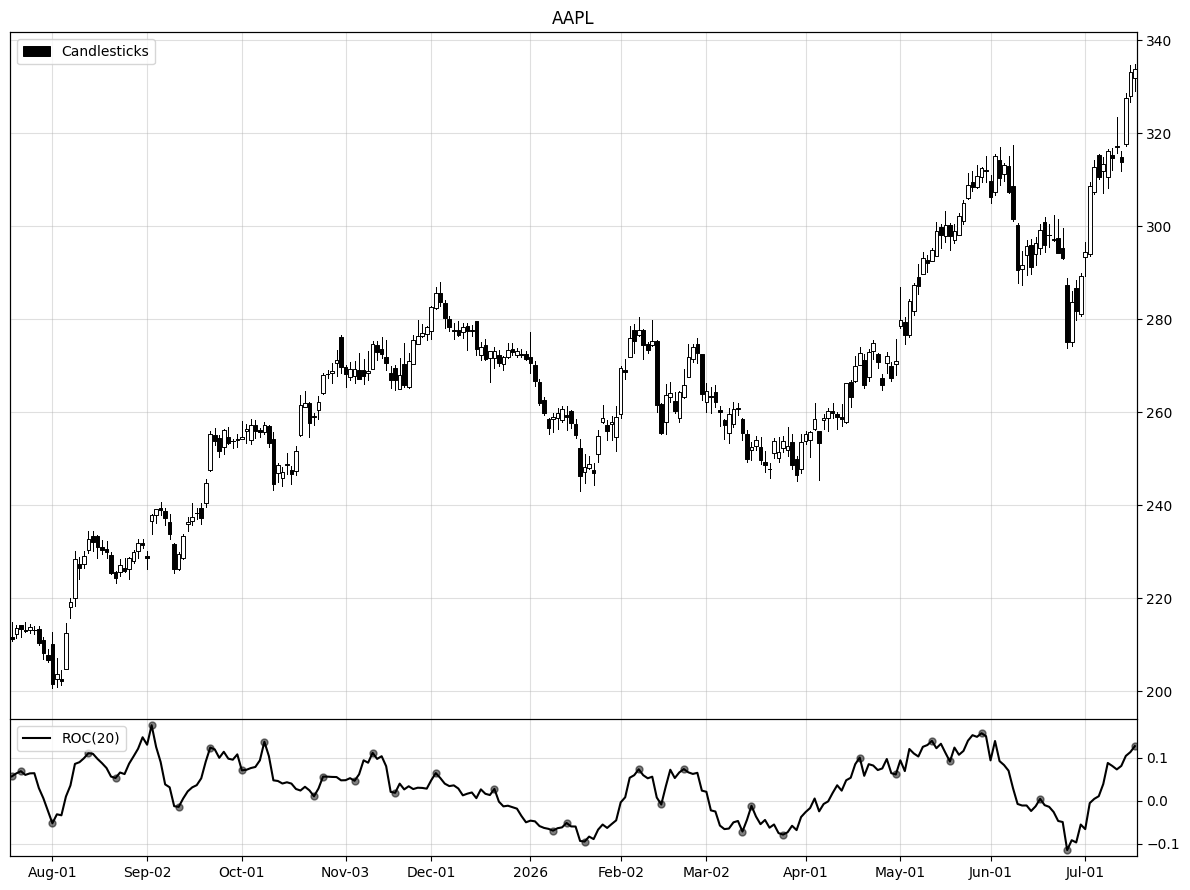

In [3]:
chart = Chart(prices, title=ticker, max_bars=250, figsize=(12, 9)).plot(
    Candlesticks(),
).pane("below").plot(
    ROC(20),
    Swings(ROC(20), span=5),
).show()